original


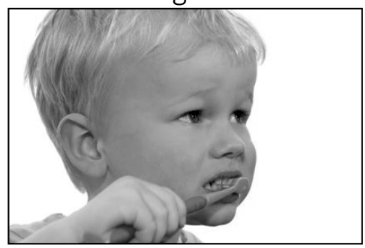

darken


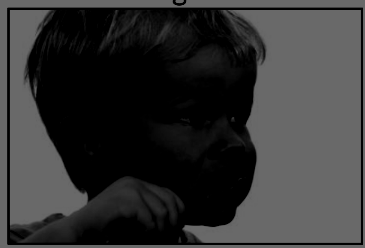

Lighten


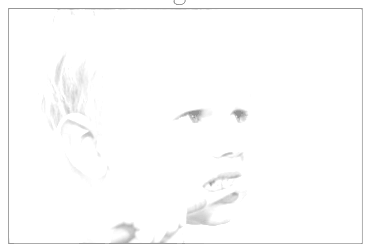

Invert


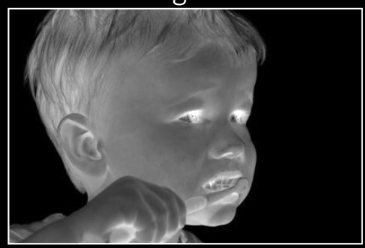

raise contrast


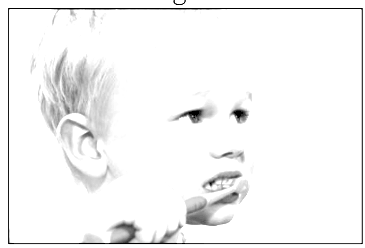

lower contrast


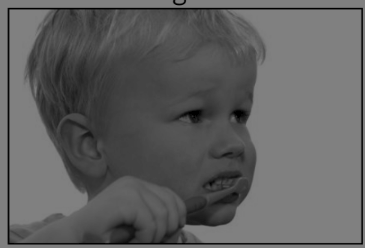

non-linear lower contrast


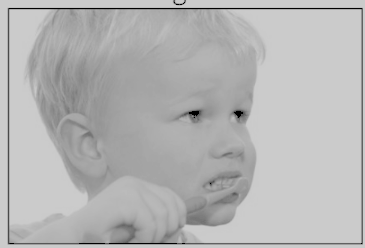

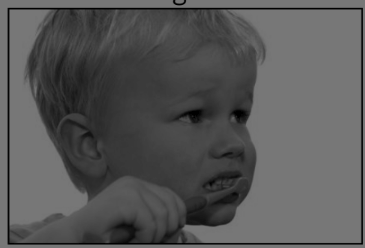

In [6]:

# prompt: point processing of images using opencv,lower contrast of original image by x/2
import cv2
from google.colab.patches import cv_imshow
import numpy as np

# image = cv2.imread('child.PNG')
path=r'/content/drive/MyDrive/CVClassLectureDemo/child.PNG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
print("original")
cv_imshow(image)
# Darken Image(x-128)
# gray_image = cv2.imread('child.PNG', cv2.IMREAD_GRAYSCALE)
gray_image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

img_dark = cv2.subtract(gray_image,150)
print("darken")
cv_imshow(img_dark)
#Ligthen Image(x+128)
img_light=cv2.add(image,150)
print("Lighten")
cv_imshow(img_light)
#Image Inversion(255-x)
img_contrast = cv2.subtract(255,image)
print("Invert")
#Raise Contrast(X x 2)
cv_imshow(img_contrast)
imgc = cv2.convertScaleAbs(image, alpha=2.0, beta=0)
print("raise contrast")
#Lower Contrast(x/2)
cv_imshow(imgc)
img = cv2.convertScaleAbs(image, alpha=0.5, beta=0)
print("lower contrast")
cv_imshow(img)
#NonLinearLowerContrast
NonLinearLowerContrast_img = np.power(img / 255.0, 0.33) * 255.0
print("non-linear lower contrast")
cv_imshow(NonLinearLowerContrast_img)
#NonLinearRaiseContrast
NonLinearRaiseContrast_img = np.power(img / 255.0, 1.1) * 255.0
cv_imshow(NonLinearRaiseContrast_img)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


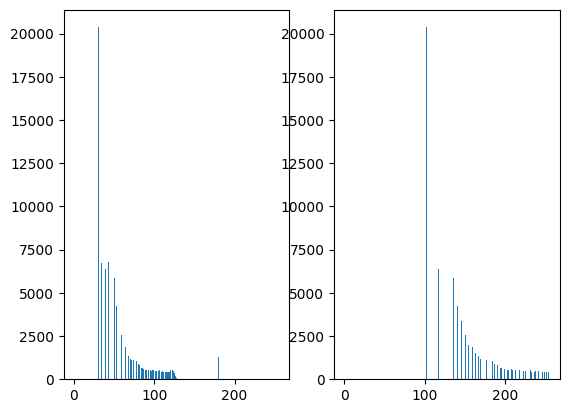

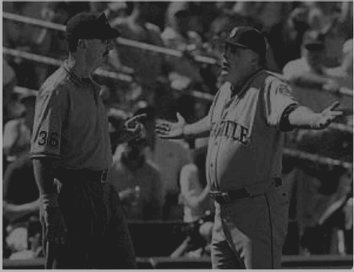

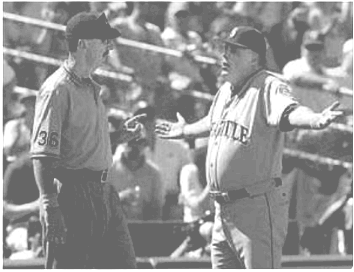

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
def linear_histogram_stretching(image):
  """Performs linear histogram stretching on an image.

  Args:
    image: A numpy array representing the image.

  Returns:
    A numpy array representing the stretched image.
  """

  # Get the minimum and maximum pixel values in the image.
  min_val = np.min(image)

  max_val = np.max(image)


  # Calculate the slope of the linear transformation function.
  slope = 255.0 / (max_val - min_val)

  # Calculate the intercept of the linear transformation function.
  intercept = min_val * slope

  # Apply the linear transformation function to each pixel in the image.
  stretched_image = slope * image + intercept

  return stretched_image

# Load the input image.
# image = cv2.imread('Umpire.PNG')
path=r'/content/drive/MyDrive/CVClassLectureDemo/Umpire.PNG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Perform linear histogram stretching on the image.
# stretched_image = linear_histogram_stretching(image)

img1 = image.ravel()
l = list(img1)
l1 = []
for i in l:
  if i <30:
    l1.append(30)
  elif i>180:
    l1.append(180)
  else:
    l1.append(i)
image = np.array(l1).reshape(image.shape)

stretched_image = linear_histogram_stretching(image)

# Plot the histograms of the original and stretched images.

plt.subplot(1,2,1)
plt.hist(image.ravel(), bins=256, range=(0, 255))
plt.subplot(1,2,2)
plt.hist(stretched_image.ravel(), bins=256, range=(0, 255))
# plt.xlabel('Pixel intensity')
# plt.ylabel('Number of pixels')
# plt.title('Histograms of original and stretched images')
plt.show()


# # Display the original and stretched images.
cv2_imshow( image)
cv2_imshow(stretched_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

Original image


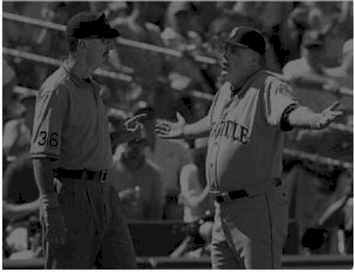

/tmp/ipython-input-554897992.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), 256, [0,256], color = 'b')


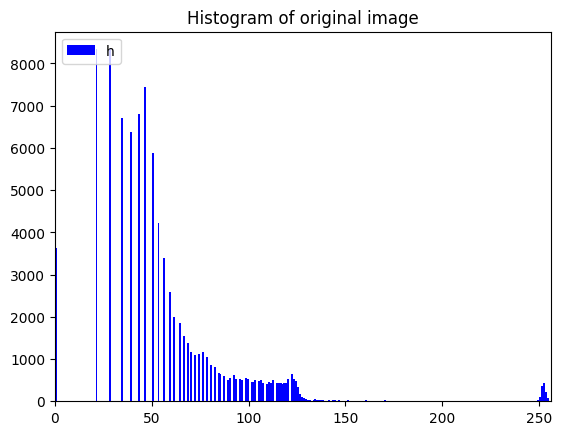

Histogram equalized image


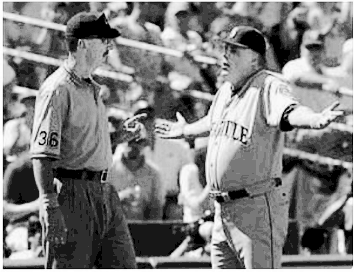

/tmp/ipython-input-554897992.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized_img.flatten(), 256, [0,256], color = 'b')


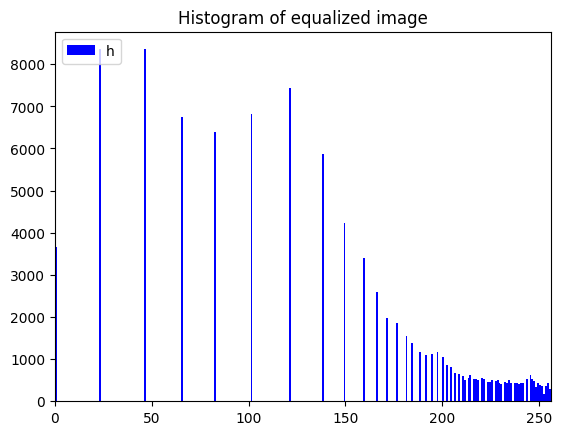

In [8]:
# Import required libraries

import numpy as np
#image='Umpire.PNG'
path=r'/content/drive/MyDrive/CVClassLectureDemo/Umpire.PNG'
#image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
print('Original image')
cv2_imshow(img)
# compute histogram of the image
hist,bins = np.histogram(img.flatten(), 256, [0,256])

plt.hist(img.flatten(), 256, [0,256], color = 'b')
plt.xlim([0,256])
plt.legend('histogram', loc = 'upper left')
plt.title('Histogram of original image')
plt.show()
equalized_img = cv2.equalizeHist(img)
print('Histogram equalized image')
cv2_imshow(equalized_img)

hist,bins = np.histogram(equalized_img.flatten(), 256, [0,256])

plt.hist(equalized_img.flatten(), 256, [0,256], color = 'b')
plt.xlim([0,256])
plt.legend('histogram', loc = 'upper left')
plt.title('Histogram of equalized image')
plt.show()